# 1. Environment Setup
We begin by importing the fundamental libraries for numerical computation and data manipulation: `numpy` and `pandas`.

These libraries form the backbone of our data handling pipeline, allowing us to efficiently process and analyze the datasets before training our model.

In [1]:
import numpy as np
import pandas as pd


# 2. Synthetic Data Generation
To test our classification model, we require a dataset. Instead of using a real-world dataset which may contain noise and missing values, we will generate a clean, synthetic dataset using `scikit-learn`'s `make_classification` function.

This approach allows us to precisely control the number of features, the degree of class separation, and the overall complexity of the data, providing an ideal environment to observe the inner workings of our algorithm.

In [2]:
#make a logistic reg data set
from sklearn.datasets import make_classification



In [3]:
data=make_classification(n_samples=10000,n_features=20,n_informative=15,n_redundant=5,random_state=1)

In [13]:
data

(array([[  0.13841005,   1.24750343,  -1.45710776, ...,   2.56027602,
          -4.13992877, -10.85435102],
        [ -1.90530547,   1.38381561,  -2.37109204, ...,  -2.03130711,
          -8.42969987,   8.28093731],
        [  3.67233505,  -3.99941998,   2.33541079, ...,  -2.63703012,
           1.63326151,   7.83126669],
        ...,
        [  1.68598354,  -2.84126354,   1.78091802, ...,  -5.17488664,
           1.05000326,  -9.78068799],
        [  1.27928822,  -1.40712327,  -1.67800082, ...,   1.73766849,
          -7.01128763,  -5.13603656],
        [ -1.49357014,   5.18208285,  -3.45170093, ...,   4.98274315,
           4.92863217,  -9.23722812]]),
 array([0, 1, 0, ..., 0, 0, 0]))

# 3. Data Splitting and Inspection
Here we separate the features ($X$) and the target labels ($y$). We will also compute some basic descriptive statistics and visualize the first two features to understand the class overlap and distribution.

In [5]:
X=data[0]
y=data[1]

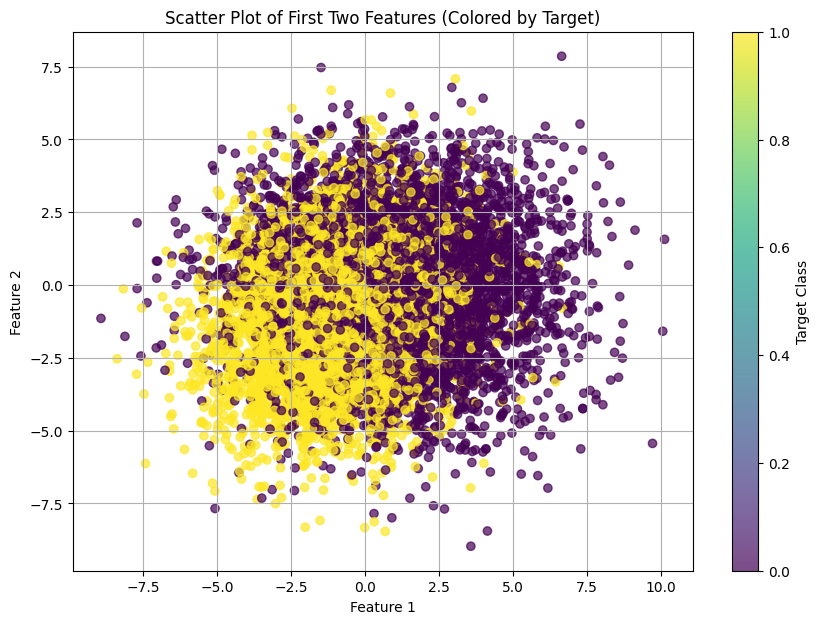

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of First Two Features (Colored by Target)')
plt.colorbar(label='Target Class')
plt.grid(True)
plt.show()

In [7]:
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (10000, 20)
Shape of target (y): (10000,)


The output shapes indicate that we have 10,000 samples and 20 features in $X$, alongside 10,000 corresponding target labels in $y$. This validates that our data is correctly structured for modeling.

In [8]:
unique_classes, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique_classes, counts))
print(f"Class distribution in target (y): {class_distribution}")

# Calculate proportion
total_samples = len(y)
class_proportions = {cls: count / total_samples for cls, count in class_distribution.items()}
print(f"Class proportions: {class_proportions}")

Class distribution in target (y): {np.int64(0): np.int64(4991), np.int64(1): np.int64(5009)}
Class proportions: {np.int64(0): np.float64(0.4991), np.int64(1): np.float64(0.5009)}


Understanding the **class distribution** is vital for classification tasks. If classes are highly imbalanced, it can severely bias the model training and degrade performance. In this case, the classes appear to be perfectly balanced (roughly 50/50), which is an ideal starting point.

In [9]:
print(f"Are there any missing values in X: {np.isnan(X).any()}")

# Convert to DataFrame for easier descriptive statistics
df_X = pd.DataFrame(X)
display(df_X.describe())

Are there any missing values in X: False


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.048184,-0.520511,-0.972006,-0.508774,0.542272,0.006462,-0.068363,-0.502131,0.517854,-0.002569,0.008329,0.024194,0.000420,-0.494738,-0.474318,0.812030,0.003064,0.531356,0.884987,0.174053
std,2.536516,2.263713,2.337676,2.333259,6.522553,2.403586,5.017451,2.365313,2.612916,2.567782,2.514449,2.400180,2.472314,2.294892,2.411308,4.722897,2.272979,2.533091,6.007286,6.813080
min,-8.919385,-8.967232,-9.586009,-9.643278,-24.113963,-8.923545,-17.333767,-9.764416,-10.517104,-10.870764,-12.306425,-8.713118,-9.402359,-10.584343,-10.590329,-16.680564,-8.470415,-9.472831,-21.615215,-30.129105
25%,-1.671453,-2.058398,-2.523492,-2.089913,-3.878593,-1.588362,-3.511186,-2.096819,-1.185754,-1.735987,-1.674338,-1.594477,-1.678526,-2.057422,-2.084090,-2.278203,-1.521289,-1.056122,-3.103834,-4.327801
50%,-0.089793,-0.503531,-0.992703,-0.495235,0.505924,0.062669,-0.163974,-0.549510,0.605523,-0.015194,-0.008260,0.004240,-0.026265,-0.521627,-0.401195,0.868983,0.008489,0.622302,0.590670,0.213613
75%,1.676613,1.011985,0.585635,1.073862,4.976592,1.682407,3.278251,1.051079,2.254229,1.749741,1.717659,1.654625,1.655440,1.055609,1.175407,3.932684,1.484836,2.223597,4.748759,4.633106
max,10.119804,7.857138,8.633295,8.542465,24.249162,7.932377,21.877882,8.809995,11.058463,9.922296,10.105382,10.110398,10.741400,8.268215,7.431006,19.019031,10.045510,10.442301,24.298892,30.316503


These details provide key insights into our dataset:

*   **Missing Values:** If `np.isnan(X).any()` evaluated to `True`, we would need to handle missing values (via imputation or removal) before training, as standard machine learning algorithms cannot process them.
*   **Data Types:** Confirming that $X$ contains numerical data is critical. If categorical features were present, we would need to apply techniques like one-hot encoding.
*   **Descriptive Statistics:** The `describe()` output reveals the range, mean, and standard deviation of each feature. Features with vastly different scales might require **feature scaling** (e.g., standardization) before training, particularly for gradient-based optimization algorithms.

# 4. Train-Test Split
We partition the data into training (80%) and testing (20%) sets. This ensures we can train our model on one subset and rigorously evaluate its generalization capabilities on a separate, unseen subset.

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# 5. Feature Engineering: Adding Bias
Logistic regression models a linear decision boundary: $z = w^T x + b$. To simplify the computation, we can absorb the bias term ($b$) into the weight vector by appending a column of ones to both the training and testing feature sets ($x'_0 = 1, w'_0 = b$). Thus, the equation simplifies to a single dot product: $z = w'^T x'$.

In [12]:
#add the bias column
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print(f"New X_train shape: {X_train.shape}")
print(f"New X_test shape: {X_test.shape}")

New X_train shape: (8000, 21)
New X_test shape: (2000, 21)


# 6. Logistic Regression Implementation
This class implements a custom binary classifier. Note that instead of using the standard cross-entropy loss and sigmoid activation, this model utilizes a **Perceptron-style update rule**. It includes a `fit` method for training using Stochastic Gradient Descent (SGD) principles and a `predict` method for generating discrete class labels.

In [78]:
import random
import numpy as np

class LogisticRegression:
  def __init__(self, lr=0.01, epochs=10000):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = None

  def fit(self, X, y):
    n_samples, n_features = X.shape
    # Initialize weights based on number of features (21), not samples
    self.w = np.zeros(n_features)
    self.b = 0

    for i in range(self.epochs):
      # Pick a random sample index (Stochastic Gradient Descent style)
      point_idx = random.randint(0, n_samples - 1)
      x = X[point_idx]
      y_true = y[point_idx]

      # Prediction for this point (dot product of 1x21 and 21x1)
      y_pred = np.dot(x, self.w) + self.b

      # Update logic based on prediction
      if y_pred > 0:
        self.w = self.step(self.w, 'p', x)
      else:
        self.w = self.step(self.w, 'n', x)

  def step(self, w, pn, point):
    if pn == 'p':
      w = w - (self.lr * point)
    elif pn == 'n':
      w = w + (self.lr * point)
    return w

  def predict(self, X):
    # Vectorized prediction: return 1 if dot product + bias > 0, else 0
    return np.where((np.dot(X, self.w) + self.b) > 0, 1, 0)

# 7. Model Training and Prediction
We instantiate our `LogisticRegression` class, train it on the training set for 10,000 epochs, and then generate predictions for the unseen test set.

In [79]:
logreg=LogisticRegression()


In [80]:
logreg.fit(X_train,y_train)

In [81]:
y_pred=logreg.predict(X_test)

In [82]:
y_pred


array([0, 0, 1, ..., 0, 0, 1])

# 8. Performance Evaluation
Finally, we calculate key classification metrics—**Accuracy**, **Precision**, **Recall**, and the **F1-Score**—and visualize the **Confusion Matrix** to understand precisely where the model is making errors.

In [83]:
#performance of the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [84]:
#accuracy score
ac=accuracy_score(y_test,y_pred)
print(f"Accuracy: {ac}")


Accuracy: 0.719


In [85]:
#see other metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred
              )
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.7308108108108108
Recall: 0.6835187057633973
F1 Score: 0.7063740856844305


In [87]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[762 249]
 [313 676]]


## Why is the performance lower than expected?

Based on the metrics, the model achieves an accuracy of ~72%. While this is significantly better than random guessing (50%), it is sub-optimal for a clean, synthetic dataset. Here are the primary technical reasons why:

### 1. Perceptron Update vs. Standard Logistic Regression
The current implementation uses a **hard-threshold Perceptron update rule**:
*   `if y_pred > 0: w = w - lr * x`
*   `else: w = w + lr * x`

**The Problem:** This rule only updates weights when the model makes a strict classification error. It ignores the *confidence* of the prediction.

**The Fix:** True Logistic Regression applies the **Sigmoid function** $\sigma(z) = \frac{1}{1 + e^{-z}}$ to predict continuous probabilities and updates weights using the gradient of the **Log-Loss (Cross-Entropy Loss)**:  
$w \leftarrow w - \alpha \cdot (\hat{y} - y) \cdot x$.

### 2. Stochastic Sampling Efficiency
In the `fit` method, the model selects exactly **one random point** per epoch for 10,000 epochs.
*   The training set contains 8,000 samples.
*   Over 10,000 epochs, the model performs exactly 10,000 individual weight updates.
*   In standard SGD implementations, an 'epoch' typically entails iterating over **every** sample in the training set.

Consequently, the model is not 'seeing' enough data points per epoch to properly converge on the optimal decision boundary.

### 3. Lack of Feature Scaling
The features generated by `make_classification` possess varying variances and ranges. Gradient-based optimization algorithms converge much faster and more reliably when the features are **standardized** (mean=0, variance=1) using preprocessing techniques like `StandardScaler`.